# 模拟任务失败
在超步2任务失败

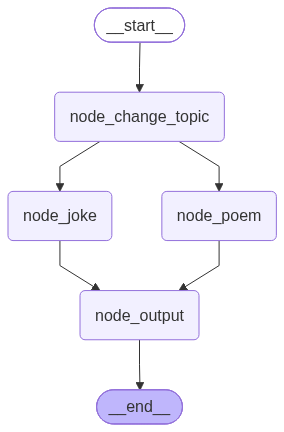

2026-08-02 16:08:29.720 | INFO     | __main__:node_change_topic:53 - topic_index:0
2026-08-02 16:08:29.722 | INFO     | __main__:node_joke:78 - node_joke正在执行
2026-08-02 16:08:29.724 | INFO     | __main__:node_poem:68 - node_poem正在执行


Exception: 任务抛出异常

In [1]:
import os
import time
from typing import TypedDict

from IPython.display import display
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from loguru import logger

load_dotenv(override=True)

# 获取大模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


# 1、声明状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    final_output: str


# 1.1、输入状态
class InputState(TypedDict):
    topic: str


# 1.2 输出状态
class OutputState(TypedDict):
    final_output: str


topics = ["布偶猫", "狸花猫", "金渐层"]
topic_index = 0


# 2. 定义节点
def node_change_topic(state: InputState) -> OverAllState:
    global topic_index

    logger.info("topic_index:{}", topic_index)
    # 获得对应topic
    sub_topic = topics[topic_index]
    # 下一个topic
    topic_index += 1
    # 避免下标越界
    topic_index %= len(topics)

    return {
        "topic": f"{state["topic"]}:{sub_topic}"
    }


# 2.1 同一个超步的位置，运行成功的节点
def node_poem(state: OverAllState) -> OverAllState:
    logger.info("node_poem正在执行")
    topic = state["topic"]
    poem = model.invoke([HumanMessage(f"写一首关于{topic}主题的七言绝句")]).content
    return {
        "poem": poem
    }


# 2.2 同一个超步运行失败的几点
def node_joke(state: OverAllState) -> OverAllState:
    logger.info("node_joke正在执行")
    topic = state["topic"]
    time.sleep(5)
    raise Exception("任务抛出异常")
    joke = model.invoke([HumanMessage(f"写一个关于{topic}主题的笑话")]).content
    return {
        "poem": joke
    }


def node_output(state: OverAllState) -> OutputState:
    logger.info("node_output正在运行")
    topic = state["topic"]
    poem = state["poem"]
    joke = state["joke"]
    final_output = f"关于{topic}的七言绝句:{poem}\n 笑话:{joke}"
    return {
        "final_output": final_output
    }


# 3、构建图
builder = StateGraph(state_schema=OverAllState, InputState=InputState, output_schema=OutputState)

# 3.1 添加节点
builder.add_node("node_change_topic", node_change_topic)
builder.add_node("node_poem", node_poem)
builder.add_node("node_joke", node_joke)
builder.add_node("node_output", node_output)

# 3.2 添加边
builder.add_edge(START, "node_change_topic")
builder.add_edge("node_change_topic", "node_poem")
builder.add_edge("node_change_topic", "node_joke")
builder.add_edge("node_poem", "node_output")
builder.add_edge("node_joke", "node_output")
builder.add_edge("node_output", END)

# 4、添加检查点（记忆保存)
DB_URL = os.getenv("DB_URL")

with PostgresSaver.from_conn_string(DB_URL) as checkpointer:
    # 5、第一次使用PostgresSaver 需要调用方法 setup
    graph = builder.compile(checkpointer=checkpointer)

    display(graph)

    config = {
        "configurable": {
            "thread_id": "chapter03-05"
        }
    }

    res = graph.invoke({"topic": "猫"}, config=config)
    print(res)